# Eigenfaces — Mathematical Presentation
## Team 4: Does the similarity metric change face recognition?

**Dataset:** Olivetti Faces — 400 grayscale images, 40 identities, 10 images per identity.

**Core question:** Can we represent a $64\times64$ face using only $k$ numbers while preserving enough information for reconstruction and recognition?

**Team 4 question:** In the learned PCA space, does changing the similarity definition from Euclidean distance to Cosine similarity change the nearest neighbor and the final identity prediction?

> **Presentation principle:** We focus on the mathematics, the geometry, the experimental evidence, and the *why*. The implementation code is intentionally omitted from this presentation notebook.


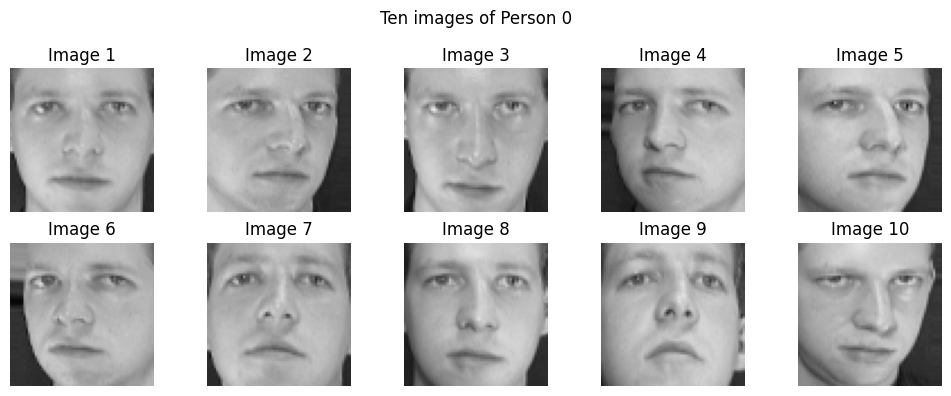
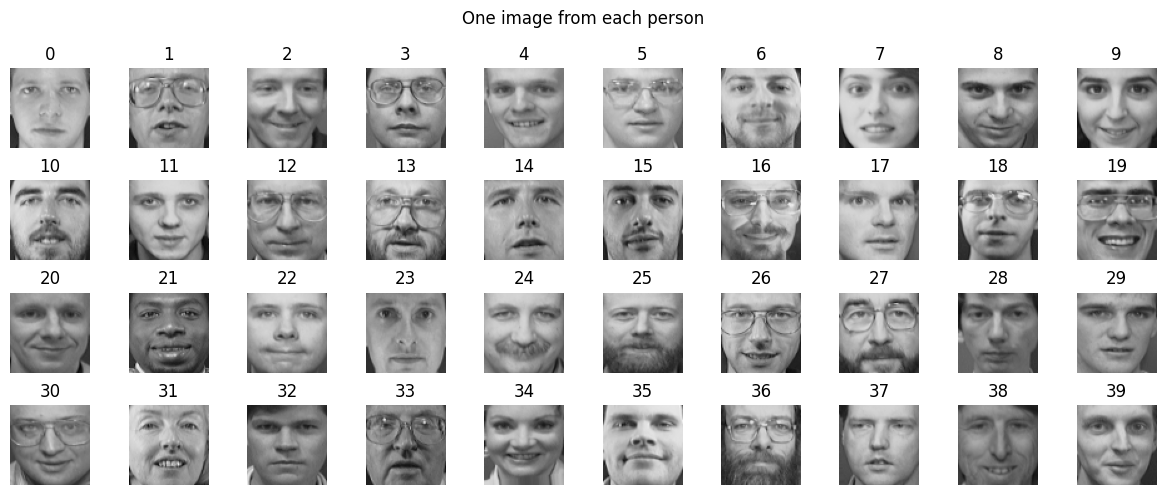

# 1. Experimental Setup

For each identity:

$$
8\text{ images} \rightarrow \text{training},
\qquad
2\text{ images} \rightarrow \text{test}.
$$

Therefore,

$$
X_{train}\in\mathbb{R}^{320\times4096},
\qquad
X_{test}\in\mathbb{R}^{80\times4096}.
$$

Each image is originally

$$
64\times64=4096
$$

pixels, so one face becomes a point in a **4096-dimensional space**.

### Critical rule: no test leakage

The mean face and all PCA directions are learned **only from the training set**. The same training mean is then used to center both training and test images.

This train/test boundary is essential: using test data to learn PCA parameters would leak information into the model.


# 2. The Mathematical Idea Behind PCA

Let

$$
X\in\mathbb{R}^{n\times d}
$$

contain one image per row.

The training mean is

$$
\boxed{
\mu=\frac{1}{n}\sum_{i=1}^{n}x_i
}
$$

and the centered data is

$$
\boxed{
X_c=X-\mathbf{1}\mu^T.
}
$$

For this project,

$$
n=320,\qquad d=4096.
$$

PCA asks:

> **In which directions does the training data vary the most?**

A principal direction $u_i$ satisfies

$$
Cu_i=\lambda_i u_i,
$$

where

$$
C=\frac{1}{n-1}X_c^TX_c.
$$

The largest eigenvalue corresponds to the direction with the largest variance.

### Why do we use the Gram matrix?

The covariance matrix is $4096\times4096$, which is large.

Instead we solve the equivalent smaller eigenvalue problem

$$
\boxed{
G=\frac{1}{n-1}X_cX_c^T
}
$$

with

$$
G\in\mathbb{R}^{320\times320}.
$$

This is the key computational trick.


### Mean face
The mean face is the reference point around which PCA models facial variation.

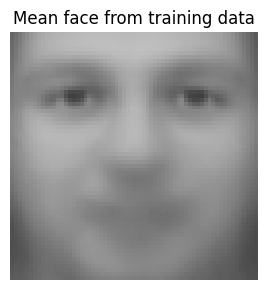

# 3. From Gram Eigenvectors to Eigenfaces

The Gram eigenproblem is

$$
Gv_i=\lambda_i v_i,
\qquad
v_i\in\mathbb{R}^{320}.
$$

But an eigenface must live in pixel space:

$$
u_i\in\mathbb{R}^{4096}.
$$

We therefore map the sample-space eigenvector back using

$$
\boxed{
w_i=X_c^Tv_i.
}
$$

Then normalize:

$$
\boxed{
u_i=\frac{w_i}{\|w_i\|_2}.
}
$$

If $v_i$ is unit length, then

$$
\|X_c^Tv_i\|_2^2
=
v_i^TX_cX_c^Tv_i
=
(n-1)v_i^TGv_i
=
(n-1)\lambda_i.
$$

Therefore,

$$
\boxed{
u_i=
\frac{X_c^Tv_i}
{\sqrt{(n-1)\lambda_i}}
}
$$

for nonzero eigenvalues.

Each $u_i$ has 4096 entries, so it can be reshaped back to

$$
64\times64
$$

and visualized as an **eigenface**.


### Eigenfaces

The first components capture the strongest directions of variation in the training data.

Importantly, an eigenface is **not** a particular person's face. It is a direction in the high-dimensional face space.

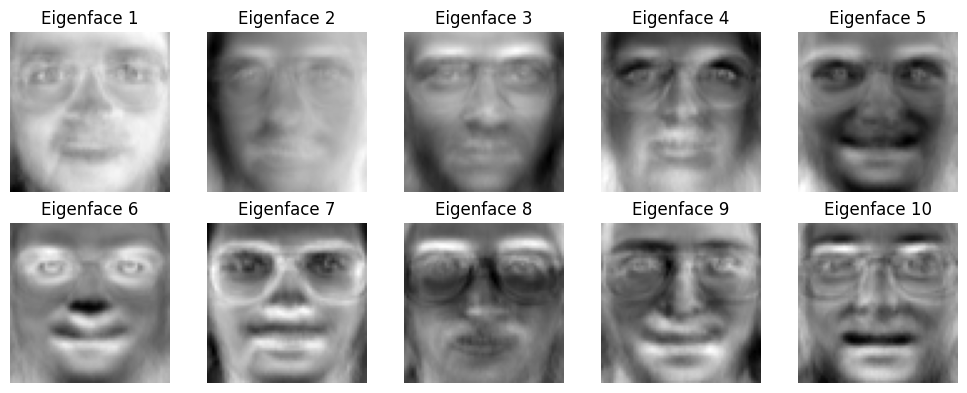

### Observed test-set results

| $k$ | Cumulative variance ratio |
|---:|---:|
| 10 | 65.96% |
| 50 | 87.85% |
| 150 | 97.06% |


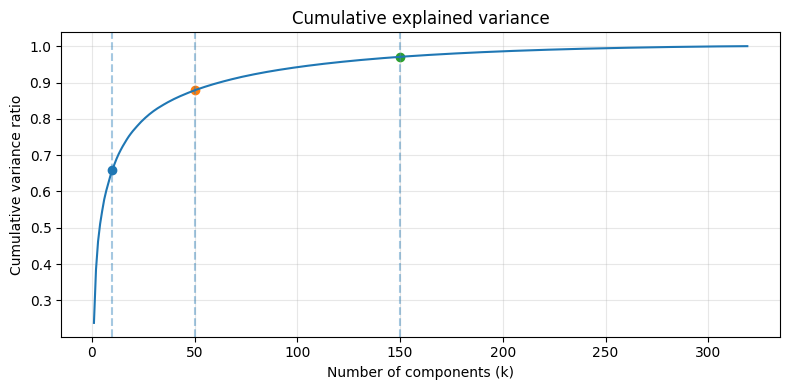

# 4. Projection = Compression

Keep the first $k$ eigenfaces:

$$
U_k=
\begin{bmatrix}
u_1&u_2&\cdots&u_k
\end{bmatrix}
\in\mathbb{R}^{4096\times k}.
$$

A centered face is compressed into

$$
\boxed{
z=x_c^TU_k
}
$$

where

$$
z\in\mathbb{R}^{k}.
$$

So:

$$
4096\text{ pixel values}
\longrightarrow
k\text{ PCA coordinates}.
$$

For example:

$$
4096\rightarrow10,\quad
4096\rightarrow50,\quad
4096\rightarrow150.
$$

Because the eigenfaces are orthonormal,

$$
U_k^TU_k=I_k.
$$

This makes the PCA coordinates genuine coordinates along mutually orthogonal directions.


# 5. Reconstruction and Reconstruction Error

From the compressed representation $z$, reconstruct:

$$
\boxed{
\hat{x}=zU_k^T+\mu.
}
$$

Equivalently,

$$
\hat{x}_c^T=x_c^TU_kU_k^T.
$$

The matrix

$$
\boxed{
P_k=U_kU_k^T
}
$$

is the orthogonal projection onto the $k$-dimensional principal subspace.

The reconstruction error is measured by

$$
\boxed{
MSE=
\frac{1}{4096}
\|x-\hat{x}\|_2^2.
}
$$

### Observed test-set results

| $k$ | Reconstruction MSE |
|---:|---:|
| 10 | 0.00706589 |
| 50 | 0.00326911 |
| 150 | 0.00205541 |

Therefore,

$$
MSE_{10}>MSE_{50}>MSE_{150}.
$$

More components preserve more information, so reconstruction improves.

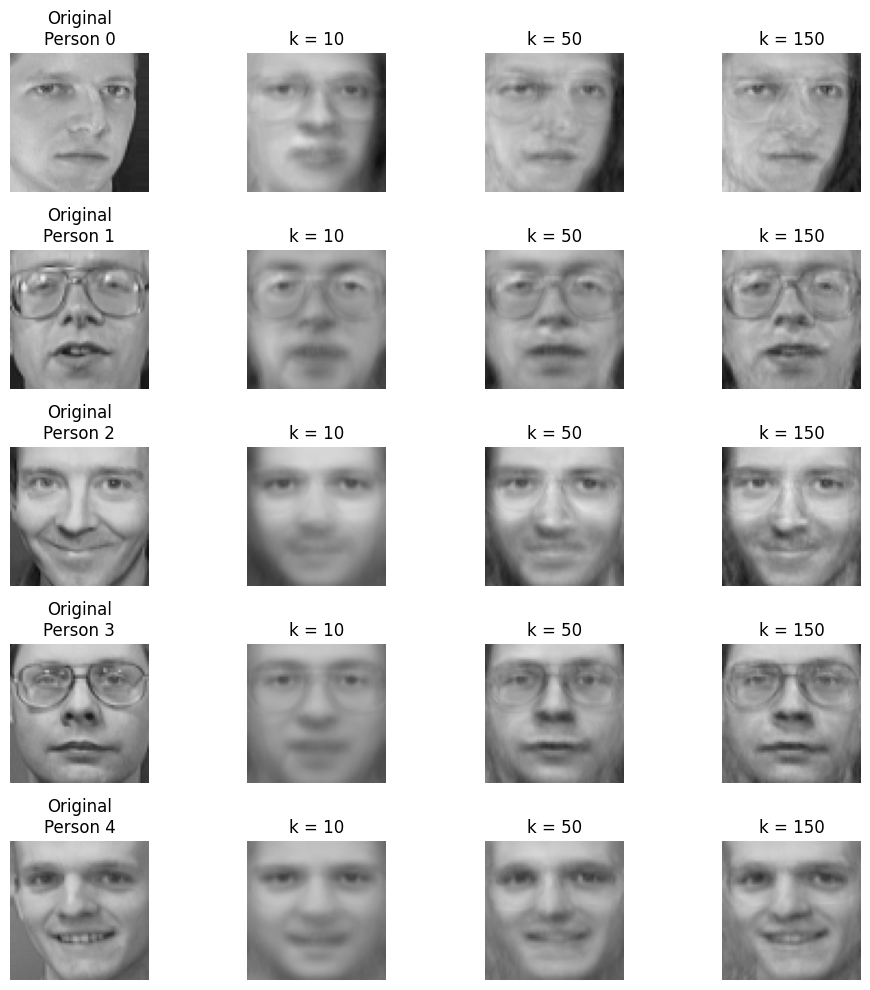


### What should we notice?

Increasing $k$ makes the reconstruction visually closer to the original.

But this does **not** yet tell us whether identity recognition improves.

That distinction becomes the central point.

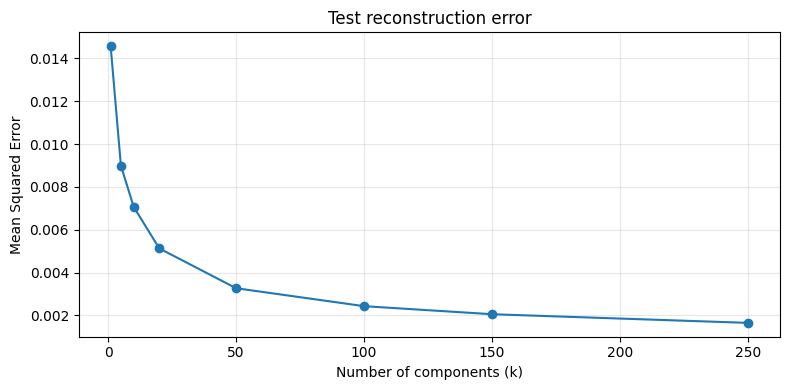


### Reconstruction error vs. $k$

The error decreases as $k$ increases. The important conceptual point is that PCA is optimizing representation/reconstruction quality — not identity classification.


# 6. Recognition in PCA Space

Once every face has been projected into the same PCA coordinate system,

$$
Z_{train}=X_{train,c}U_k,
\qquad
Z_{test}=X_{test,c}U_k.
$$

For a test vector $z_{test}$, compare it with every training vector $z_i$.

## Euclidean distance

$$
\boxed{
d_E(z_{test},z_i)
=
\|z_{test}-z_i\|_2
}
$$

and choose

$$
\boxed{
i^*=\arg\min_i d_E(z_{test},z_i).
}
$$

## Cosine similarity

$$
\boxed{
s_{cos}(z_{test},z_i)
=
\frac{z_{test}^Tz_i}
{\|z_{test}\|_2\,\|z_i\|_2}
}
$$

and choose

$$
\boxed{
i^*=\arg\max_i s_{cos}(z_{test},z_i).
}
$$

The predicted identity is simply the label of the selected training image:

$$
\boxed{
\hat y=y_{i^*}.
}
$$

So Team 4 changes **only the similarity rule** while keeping the PCA representation fixed.


# 7. Euclidean vs. Cosine

### Experimental results on the 80 test images

| $k$ | Euclidean | Cosine |
|---:|---:|---:|
| 10 | **92.50%** | **87.50%** |
| 50 | **93.75%** | **93.75%** |
| 150 | **93.75%** | **93.75%** |

### First conclusion

For this dataset and split:

- Euclidean is better at $k=10$.
- At $k=50$ and $k=150$, both metrics reach the same accuracy.
- Therefore, we cannot claim that Cosine is universally better.
- Euclidean appears slightly more suitable for this experiment because it is never worse and performs better at the smallest tested $k$.

But there is a subtle result:

> **Equal accuracy does not mean equal decisions.**

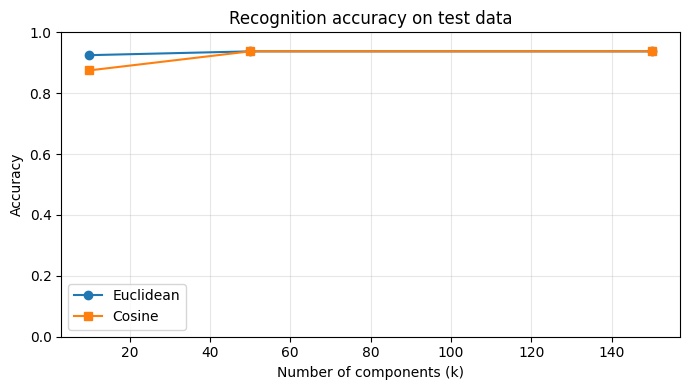


# 8. Why Can Two Metrics Give the Same Accuracy?

At $k=50$, the two metrics selected **different training neighbors for 5 of the 80 test images**.

However, they produced **different identity predictions for only 1 image**.

Why?

Because a nearest-neighbor index and a predicted identity are not the same thing.

Suppose:

$$
\text{Euclidean}\rightarrow \text{training image of identity }7
$$

and

$$
\text{Cosine}\rightarrow \text{another training image of identity }7.
$$

The neighbors are different, but

$$
\boxed{\hat y_E=\hat y_C=7.}
$$

So the metric can change the *specific neighbor* without changing the final classification.

This is exactly why comparing only accuracy can hide interesting behavior.

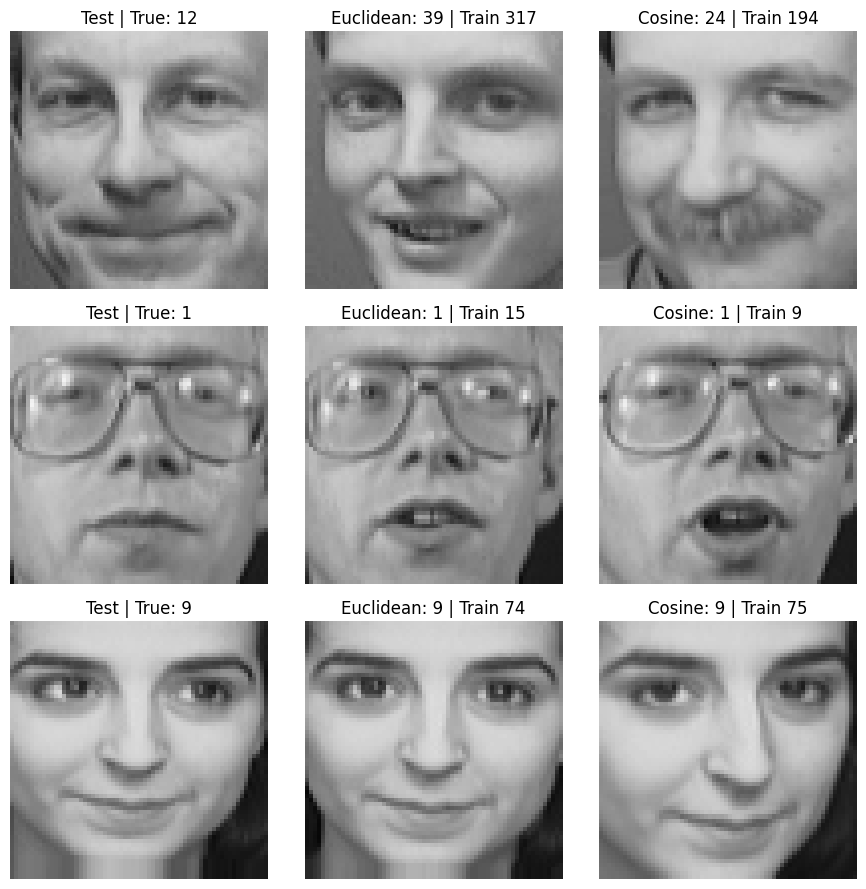


### The geometric reason

Euclidean distance asks:

> **How far apart are the two points?**

Cosine similarity asks:

> **How similar is their direction from the origin?**

For example, vectors on the same ray can have cosine similarity $1$, even if their Euclidean distance is large.

So the two metrics define different notions of “similar face.”


# 9. Why Does Component Scale Matter?

PCA components are ordered by decreasing variance:

$$
\lambda_1\ge\lambda_2\ge\cdots
$$

so early PCA coordinates typically have larger numerical variation than later ones.

Euclidean distance is sensitive to coordinate scale:

$$
\|a-b\|_2^2
=
\sum_j(a_j-b_j)^2.
$$

A coordinate with larger numerical variation can contribute more strongly to this sum.

Cosine similarity normalizes the total vector length:

$$
\frac{a^Tb}{\|a\|\|b\|},
$$

so it focuses mainly on **direction** rather than overall magnitude.

### Important nuance

This does not imply that Cosine is automatically better.

The correct scientific question is:

$$
\boxed{
\text{Which notion of similarity better separates identities in this dataset?}
}
$$

Our measured evidence favors Euclidean slightly, especially at $k=10$, while both metrics are equivalent in accuracy at $k=50$ and $150$.


# 10. Why Didn't Recognition Improve from $k=50$ to $k=150$?

This is one of the most important conceptual questions.

### Reconstruction objective

PCA tries to preserve variance and minimize reconstruction error:

$$
\min \|X_c-X_cU_kU_k^T\|_F^2.
$$

Therefore, increasing $k$ gives the model more information and cannot increase the optimal reconstruction error.

### Recognition objective

Recognition asks whether identities are separated correctly:

$$
\text{same identity}\rightarrow\text{close},
\qquad
\text{different identities}\rightarrow\text{far}.
$$

These are **different objectives**.

Additional components can encode:

- illumination,
- expression,
- pose,
- fine image-specific details,
- other variation that is real but not identity-specific.

Thus:

$$
\boxed{
\text{lower reconstruction error}
\not\Rightarrow
\text{higher recognition accuracy}.
}
$$

Our result demonstrates this directly:

$$
MSE_{50}>MSE_{150},
$$

but

$$
Accuracy_{50}=Accuracy_{150}=93.75\%.
$$

So the extra information improves reconstruction without changing the nearest-neighbor identity decision.


# 11. Failure Case: What Does a Wrong Prediction Mean?

A recognition failure occurs when

$$
\boxed{\hat y\neq y}.
$$

Geometrically, the selected wrong identity is closer under the chosen metric than the correct training candidates:

$$
\|z_{test}-z_{wrong}\|_2
<
\|z_{test}-z_{correct}\|_2.
$$

This does **not** mean PCA is mathematically wrong.

It means that the learned representation plus the selected similarity metric does not perfectly separate all identities.

Possible causes supported by the project analysis include:

- similar facial structure,
- illumination differences,
- facial expression,
- pose differences,
- only 8 training images per identity,
- information discarded by dimensionality reduction,
- limitations of a simple nearest-neighbor metric.

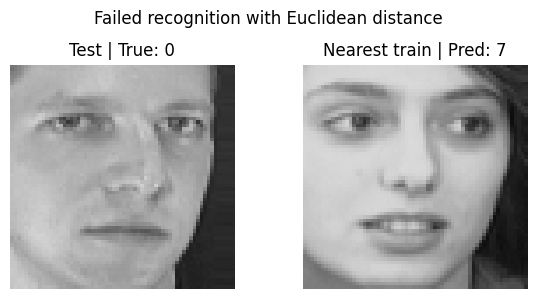

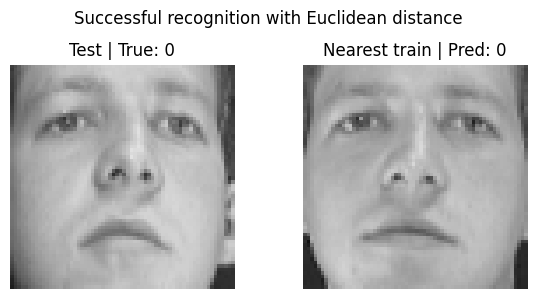

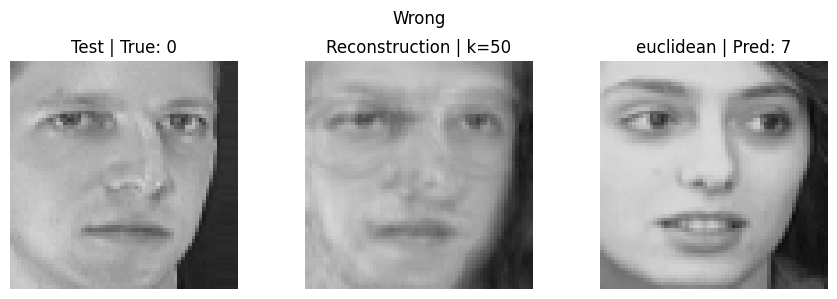


### How to defend the failure

The right explanation is not “the algorithm made a random mistake.”

Instead:

> The test face is represented in the learned PCA space. Under the selected metric, a training face from another identity is closer than the correct identity's training examples. Therefore the nearest-neighbor rule makes a plausible but incorrect local decision.

That is a real limitation of the representation-and-metric combination.


# 12. Why Compare PCA with SVD?

The same centered training matrix can be factorized as

$$
\boxed{
X_c=U\Sigma V^T.
}
$$

Then

$$
X_c^TX_c
=
V\Sigma^T\Sigma V^T.
$$

Therefore, the right singular vectors in $V$ are the same principal directions obtained from the covariance formulation, up to sign and numerical precision.

The eigenvalues satisfy

$$
\boxed{
\lambda_i=\frac{\sigma_i^2}{n-1}
}
$$

for the covariance scaling used here.

### Project result

The first 10 eigenvalues from the two routes matched:

$$
\boxed{\text{True}}
$$

and the mean squared difference between Gram/PCA and SVD reconstructions at $k=50$ was

$$
\boxed{2.39\times10^{-31}}.
$$

This is numerical agreement, not merely visual similarity.


# 13. Sign Ambiguity: Why Can Eigenfaces Look Opposite?

If

$$
Au=\lambda u,
$$

then

$$
A(-u)=\lambda(-u).
$$

So both $u$ and $-u$ are valid eigenvectors.

Therefore, PCA and SVD may return the same direction with opposite signs.

The correct comparison is not:

$$
u_i\stackrel{?}{=}v_i
$$

pixel-by-pixel.

Instead compare the subspaces:

$$
P_{PCA}=Q_{PCA}Q_{PCA}^T,
\qquad
P_{SVD}=Q_{SVD}Q_{SVD}^T.
$$

If

$$
\|P_{PCA}-P_{SVD}\|_F\approx0,
$$

the two methods span essentially the same principal subspace.

### Key idea

$$
\boxed{
\text{The direction matters; the arbitrary sign does not.}
}


# 14. Final Results — One Slide

### What did we learn?

**1. Compression**

$$
4096\text{ dimensions}\rightarrow k\text{ dimensions}
$$

while preserving useful facial structure.

**2. Reconstruction**

$$
0.00707\;(k=10)
>
0.00327\;(k=50)
>
0.00206\;(k=150).
$$

**3. Recognition**

$$
\text{Euclidean: }92.50\%,93.75\%,93.75\%
$$

$$
\text{Cosine: }87.50\%,93.75\%,93.75\%.
$$

**4. Team 4 result**

Changing the similarity definition can change the selected neighbor. At $k=50$, 5 test samples had different neighbors, but only 1 had a different predicted identity.

**5. Key conceptual result**

$$
\boxed{
\text{better reconstruction}\neq\text{better recognition}
}
$$

**6. Limitation**

The model uses a fixed small dataset, a simple nearest-neighbor classifier, and a single train/test split. Therefore the metric conclusion is specific to this experiment, not a universal law.


# 15. The 30-Second Defense Sheet

### If they ask: “Why center the data?”

Because PCA should model **variation around the mean**, not the absolute brightness/location of the data.

### “Why use the Gram matrix?”

Because $4096\times4096$ covariance is much larger than the equivalent $320\times320$ Gram problem.

### “Why normalize eigenfaces?”

To make the principal directions unit vectors so their coordinates have a consistent orthonormal geometry.

### “Why does MSE decrease with $k$?”

Because the PCA subspaces are nested:

$$
\mathcal S_1\subseteq\mathcal S_2\subseteq\cdots
$$

so adding a component cannot make the best orthogonal projection worse.

### “Why doesn't accuracy necessarily increase?”

Because PCA preserves variance, not identity discrimination.

### “Why can Euclidean and Cosine choose different neighbors?”

Euclidean uses both magnitude and direction; Cosine mainly compares direction.

### “Why can accuracy still be identical?”

Different training images can belong to the same identity.

### “Which metric is better?”

For **this experiment**, Euclidean is slightly better: 92.5% vs 87.5% at $k=10$, while both reach 93.75% at $k=50$ and $150$. This is not a universal conclusion.

### “Why can PCA and SVD look different?”

Eigenvector signs are arbitrary. Compare the subspace or reconstruction, not raw signs.

### “What is the main limitation?”

The learned PCA representation and simple nearest-neighbor metric do not perfectly separate every identity.
